# Model 1A, CatBoost Audit 01: CatBoost 04 subgroup reliability and SHAP explanations

This append-only diagnostic notebook audits the already selected CatBoost 1A Experiment 04. It does not search for a classifier, feature manifest, probability correction, or operating threshold. The model remains fixed at 683 trees, depth 6, learning rate 0.03, L2 leaf regularization 3, no class weighting, the 41-field CatBoost 04 manifest, and the training-selected 0.31 threshold.

The fixed model is trained on all eligible 2019 JFK departures. Model behavior is examined on 2023 by month, time of day, airline, route, weather, and planned-traffic level. CatBoost SHAP values provide global and individual-flight explanations. The three established feature paths are paired only in memory, no prediction or combined-feature dataset is written, and 2024 is never loaded. The final-tail assignment caveat remains unchanged.


In [1]:
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score,
)

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
FIXED_ITERATIONS = 683
FIXED_DEPTH = 6
FIXED_LEARNING_RATE = 0.03
FIXED_L2_LEAF_REG = 3
FIXED_THRESHOLD = 0.31
N_JOBS = 4
SHAP_SAMPLE_ROWS = 5_000
MIN_GROUP_ROWS = 500

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost {catboost.__version__}")


CatBoost 1.2.10


## Pair and validate the three established feature paths

The audit repeats CatBoost 04's strict row-identity and causal-state checks before combining columns in memory. This makes the diagnostic independently reproducible while preserving the established feature files.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required audit files: {required}")


ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES", "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF", "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES", "ROTATION_ACTUAL_TURN_MINUTES",
    "ROTATION_LOG_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
    "ROTATION_INBOUND_DELAYED_15", "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC", "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC", "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
combined_frames = {}
source_rows = []
for partition, year in (("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)):
    feature_dir = PROJECT_ROOT / "data/features"
    paths = {
        "rotation": feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv",
        "airport": feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv",
        "airline": feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv",
    }
    rotation = pd.read_csv(paths["rotation"], low_memory=False)
    airport = pd.read_csv(paths["airport"], low_memory=False)
    airline = pd.read_csv(paths["airline"], low_memory=False)
    assert len(rotation) == len(airport) == len(airline)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airport[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline[IDENTITY_COLUMNS], check_dtype=False)
    assert not set(ROTATION_FEATURES + ROTATION_AUDIT_COLUMNS).difference(rotation.columns)
    assert not set(COMPACT_BACKLOG_FEATURES).difference(airport.columns)
    assert not set(FULL_AIRLINE_BACKLOG_FEATURES).difference(airline.columns)

    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()
    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    assert not rotation.loc[arrived.eq(0), [
        "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
        "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    ]].notna().any().any()

    airline_scheduled = pd.to_numeric(airline[f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT"], errors="raise")
    airline_completed = pd.to_numeric(airline[f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT"], errors="raise")
    airline_pending = pd.to_numeric(airline[f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT"], errors="raise")
    airline_delayed = pd.to_numeric(airline[f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT"], errors="raise")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = airport[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()),
    })

source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows
partition,,,,,
training,2019,107430,0.1877,0.9665,3133
validation,2023,109983,0.2364,0.9554,3565


## Reproduce the frozen CatBoost 04 model

The exact 41 source fields and 24-hour rotation mask are fixed before the audit. Training uses all 2019 rows. The 2023 target is used only to calculate the already-declared validation and diagnostic measures.


In [3]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature", "HourlyPrecipitation",
    "HourlyRelativeHumidity", "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
CATEGORICAL_FEATURES = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
NUMERIC_FEATURES = [
    *BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES,
    *SELECTED_AIRLINE_BACKLOG_FEATURES,
]
MODEL_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
CONTEXT_COLUMNS = list(dict.fromkeys([
    "FlightDate", "Flight_Number_Reporting_Airline", "Tail_Number", "Origin", "DATE",
    TARGET, *MODEL_FEATURES,
]))
assert len(CATEGORICAL_FEATURES) == 6 and len(NUMERIC_FEATURES) == 35 and len(MODEL_FEATURES) == 41
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut", "WheelsOff",
    "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay", "ArrDelayMinutes", "ArrDel15",
    "ActualElapsedTime", "AirTime", "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(MODEL_FEATURES)


def prepare(source: pd.DataFrame) -> pd.DataFrame:
    frame = mask_long_turns(source)[CONTEXT_COLUMNS].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_df = prepare(combined_frames["training"])
validation_df = prepare(combined_frames["validation"])
assert train_df["FlightDate"].max() < validation_df["FlightDate"].min()
X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET]
X_validation, y_validation = validation_df[MODEL_FEATURES], validation_df[TARGET]

model = CatBoostClassifier(
    iterations=FIXED_ITERATIONS, loss_function="Logloss", eval_metric="PRAUC:type=Classic",
    depth=FIXED_DEPTH, learning_rate=FIXED_LEARNING_RATE, l2_leaf_reg=FIXED_L2_LEAF_REG,
    random_seed=RANDOM_STATE, thread_count=N_JOBS, allow_writing_files=False, verbose=False,
)
fit_start = perf_counter()
model.fit(X_train, y_train, cat_features=CATEGORICAL_FEATURES, verbose=False)
fit_seconds = perf_counter() - fit_start
probabilities = model.predict_proba(X_validation)[:, 1]
predictions = (probabilities >= FIXED_THRESHOLD).astype(int)
reproduction = pd.Series({
    "fit_seconds": fit_seconds, "rows": len(y_validation), "prevalence": y_validation.mean(),
    "average_precision": average_precision_score(y_validation, probabilities),
    "roc_auc": roc_auc_score(y_validation, probabilities),
    "brier_score": brier_score_loss(y_validation, probabilities),
    "threshold": FIXED_THRESHOLD, "accuracy": accuracy_score(y_validation, predictions),
    "balanced_accuracy": balanced_accuracy_score(y_validation, predictions),
    "precision": precision_score(y_validation, predictions),
    "recall": recall_score(y_validation, predictions), "f1": f1_score(y_validation, predictions),
    "mcc": matthews_corrcoef(y_validation, predictions),
}, name="CatBoost 04 reproduction")
assert abs(reproduction["average_precision"] - 0.7526) < 0.0001
assert abs(reproduction["roc_auc"] - 0.8546) < 0.0001
assert abs(reproduction["brier_score"] - 0.1086) < 0.0001
reproduction.to_frame()


,CatBoost 04 reproduction
fit_seconds,26.6738
rows,"109,983.0000"
prevalence,0.2364
average_precision,0.7526
roc_auc,0.8546
brier_score,0.1086
threshold,0.3100
accuracy,0.8516
balanced_accuracy,0.7598
precision,0.7327


## Define the predeclared 2023 audit groups

Month, clock-time band, reporting airline, and destination route are direct operational groups. Weather groups use transparent priority rules: visibility below five miles, measurable precipitation, wind of at least 15 mph, then nominal conditions. Planned traffic is the sum of the six previous/current/next-hour ASPM counts; its quartile boundaries are learned from 2019 only and then applied unchanged to 2023. Route rows below 500 observations are reported together as `OTHER_LT_500` so unstable small groups do not dominate the audit.


In [4]:
def hhmm_to_minutes(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce")
    return (numeric // 100) * 60 + (numeric % 100)


def add_audit_groups(frame: pd.DataFrame, traffic_edges=None):
    result = frame.copy()
    result["AUDIT_MONTH"] = result["FlightDate"].dt.strftime("%b")
    departure_minutes = hhmm_to_minutes(result["CRSDepTime"])
    result["AUDIT_TIME_OF_DAY"] = pd.cut(
        departure_minutes, bins=[-1, 359, 719, 1079, 1439],
        labels=["00:00-05:59", "06:00-11:59", "12:00-17:59", "18:00-23:59"],
    ).astype("string")
    result["AUDIT_AIRLINE"] = result["Reporting_Airline"].astype("string")
    result["AUDIT_ROUTE"] = result["Dest"].astype("string")
    visibility = pd.to_numeric(result["HourlyVisibility"], errors="coerce")
    precipitation = pd.to_numeric(result["HourlyPrecipitation"], errors="coerce").fillna(0)
    wind = pd.to_numeric(result["HourlyWindSpeed"], errors="coerce")
    result["AUDIT_WEATHER"] = np.select(
        [visibility.lt(5), precipitation.gt(0), wind.ge(15)],
        ["LOW_VISIBILITY", "PRECIPITATION", "HIGH_WIND"], default="NOMINAL",
    )
    traffic_columns = [column for column in BASE_NUMERIC_FEATURES if column.startswith("ASPM_")]
    result["AUDIT_TRAFFIC_TOTAL"] = result[traffic_columns].sum(axis=1, min_count=1)
    if traffic_edges is None:
        inner = result["AUDIT_TRAFFIC_TOTAL"].quantile([0.25, 0.50, 0.75]).to_numpy()
        traffic_edges = np.r_[-np.inf, np.unique(inner), np.inf]
        assert len(traffic_edges) == 5
    result["AUDIT_TRAFFIC_LEVEL"] = pd.cut(
        result["AUDIT_TRAFFIC_TOTAL"], bins=traffic_edges,
        labels=["Q1_LOW", "Q2", "Q3", "Q4_HIGH"], include_lowest=True,
    ).astype("string")
    return result, traffic_edges


train_audit, traffic_edges = add_audit_groups(train_df)
validation_audit, _ = add_audit_groups(validation_df, traffic_edges=traffic_edges)
route_counts = validation_audit["AUDIT_ROUTE"].value_counts()
small_routes = route_counts[route_counts < MIN_GROUP_ROWS].index
validation_audit.loc[validation_audit["AUDIT_ROUTE"].isin(small_routes), "AUDIT_ROUTE"] = "OTHER_LT_500"
validation_audit["probability"] = probabilities
validation_audit["prediction"] = predictions
print("2019-derived planned-traffic edges:", traffic_edges)
validation_audit[[
    "AUDIT_MONTH", "AUDIT_TIME_OF_DAY", "AUDIT_AIRLINE", "AUDIT_ROUTE",
    "AUDIT_WEATHER", "AUDIT_TRAFFIC_LEVEL",
]].nunique()


2019-derived planned-traffic edges: [  -inf 170.25 195.   213.      inf]


AUDIT_MONTH            12
AUDIT_TIME_OF_DAY       4
AUDIT_AIRLINE           8
AUDIT_ROUTE            41
AUDIT_WEATHER           4
AUDIT_TRAFFIC_LEVEL     4
dtype: int64

## Measure ranking, probability quality, and threshold behavior by group

Average precision is interpreted alongside each group's prevalence. ROC AUC is omitted only if a group contains one outcome class. `calibration_gap` is mean predicted probability minus observed prevalence: positive values indicate overprediction and negative values indicate underprediction. The fixed 0.31 threshold is used everywhere.


In [5]:
def group_metrics(frame: pd.DataFrame, dimension: str) -> pd.DataFrame:
    rows = []
    for group, values in frame.groupby(dimension, observed=True, dropna=False):
        y = values[TARGET].to_numpy()
        p = values["probability"].to_numpy()
        predicted = values["prediction"].to_numpy()
        rows.append({
            "dimension": dimension.removeprefix("AUDIT_").lower(), "group": str(group),
            "rows": len(values), "prevalence": y.mean(), "mean_probability": p.mean(),
            "calibration_gap": p.mean() - y.mean(),
            "average_precision": average_precision_score(y, p) if y.sum() else np.nan,
            "roc_auc": roc_auc_score(y, p) if np.unique(y).size == 2 else np.nan,
            "brier_score": brier_score_loss(y, p),
            "precision": precision_score(y, predicted, zero_division=0),
            "recall": recall_score(y, predicted, zero_division=0),
            "f1": f1_score(y, predicted, zero_division=0),
            "mcc": matthews_corrcoef(y, predicted),
        })
    return pd.DataFrame(rows)


AUDIT_DIMENSIONS = [
    "AUDIT_MONTH", "AUDIT_TIME_OF_DAY", "AUDIT_AIRLINE", "AUDIT_ROUTE",
    "AUDIT_WEATHER", "AUDIT_TRAFFIC_LEVEL",
]
group_results = pd.concat(
    [group_metrics(validation_audit, dimension) for dimension in AUDIT_DIMENSIONS],
    ignore_index=True,
)
group_results = group_results.sort_values(["dimension", "group"]).reset_index(drop=True)
group_results


,dimension,group,rows,prevalence,mean_probability,calibration_gap,average_precision,roc_auc,brier_score,precision,recall,f1,mcc
0,airline,9E,10174,0.1602,0.1582,-0.0020,0.7405,0.8753,0.0740,0.6923,0.6239,0.6563,0.5959
1,airline,AA,13757,0.1511,0.1555,0.0045,0.5954,0.7961,0.0894,0.6084,0.4644,0.5267,0.4611
2,airline,AS,4129,0.1439,0.1743,0.0304,0.7230,0.8465,0.0662,0.7443,0.6077,0.6691,0.6242
3,airline,B6,36121,0.3555,0.2876,-0.0679,0.8115,0.8494,0.1455,0.7675,0.6333,0.6940,0.5546
4,airline,DL,28682,0.2176,0.1882,-0.0294,0.6787,0.8086,0.1147,0.6959,0.4994,0.5815,0.4987
5,airline,HA,362,0.2928,0.1600,-0.1328,0.7913,0.8564,0.1704,1.0000,0.2925,0.4526,0.4756
6,airline,OO,4350,0.2269,0.2081,-0.0188,0.7949,0.8673,0.0911,0.7880,0.6363,0.7040,0.6345
7,airline,YX,12408,0.1224,0.1364,0.0140,0.7421,0.8849,0.0545,0.7296,0.6432,0.6837,0.6443
8,month,Apr,9489,0.2667,0.2359,-0.0308,0.7810,0.8597,0.1145,0.7433,0.6314,0.6828,0.5832
9,month,Aug,9111,0.2500,0.2316,-0.0184,0.7646,0.8579,0.1114,0.7088,0.6185,0.6606,0.5596


In [6]:
audit_summary = (group_results.groupby("dimension")
    .agg(groups=("group", "size"), min_rows=("rows", "min"),
         min_ap=("average_precision", "min"), max_ap=("average_precision", "max"),
         min_recall=("recall", "min"), max_recall=("recall", "max"),
         worst_absolute_calibration_gap=("calibration_gap", lambda s: s.abs().max()),
         max_brier=("brier_score", "max")))
audit_summary


,groups,min_rows,min_ap,max_ap,min_recall,max_recall,worst_absolute_calibration_gap,max_brier
dimension,,,,,,,,
airline,8,362,0.5954,0.8115,0.2925,0.6432,0.1328,0.1704
month,12,8596,0.6499,0.8201,0.4343,0.6895,0.0453,0.1372
route,41,588,0.5747,0.8341,0.3067,0.7259,0.1014,0.1716
time_of_day,4,682,0.2257,0.8429,0.0759,0.7144,0.0375,0.1276
traffic_level,4,18497,0.5601,0.8145,0.3785,0.6739,0.0364,0.1262
weather,4,6510,0.7308,0.8196,0.5563,0.6842,0.0364,0.1249


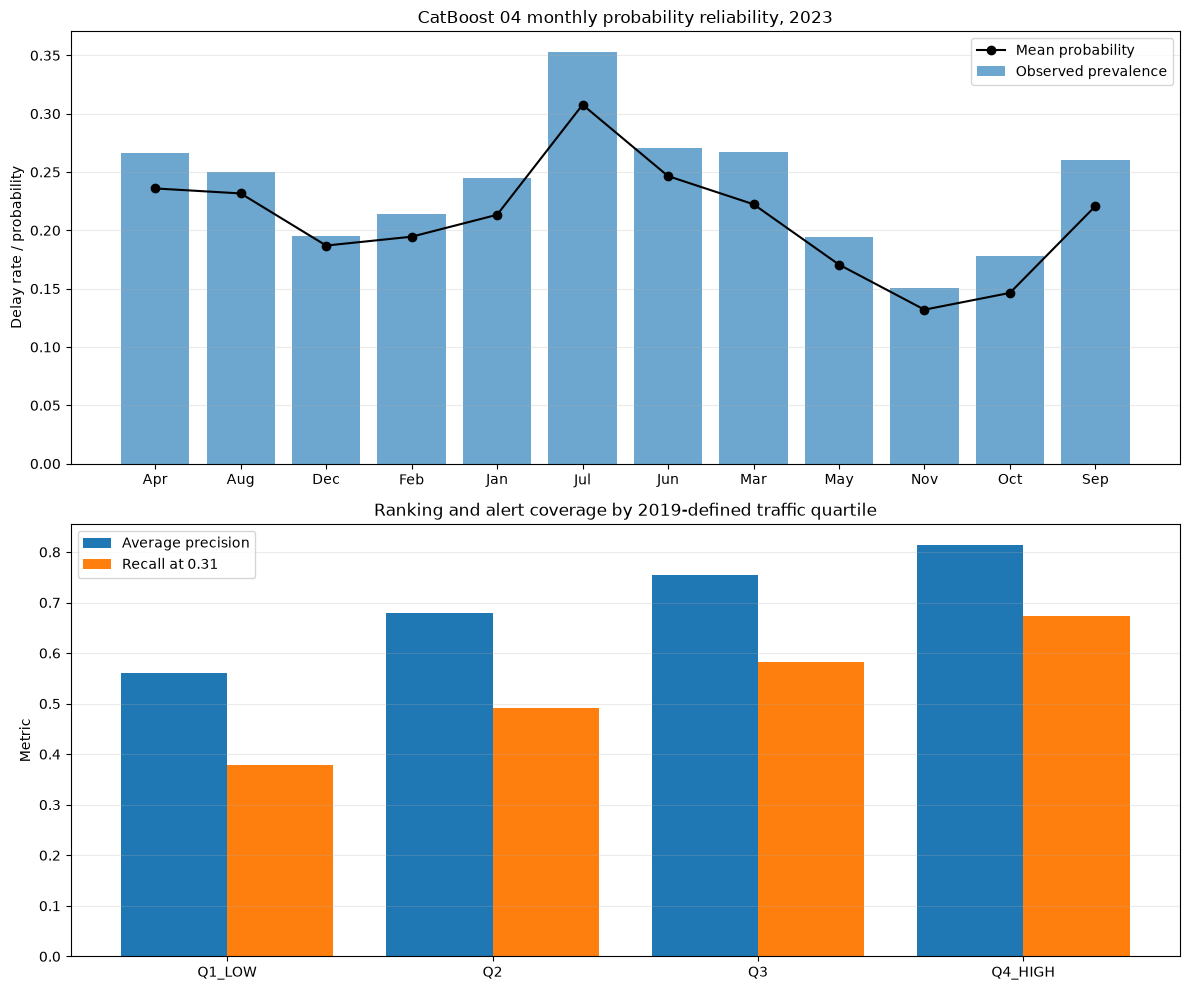

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
month = group_results[group_results["dimension"].eq("month")]
axes[0].bar(month["group"], month["prevalence"], alpha=0.65, label="Observed prevalence")
axes[0].plot(month["group"], month["mean_probability"], marker="o", color="black", label="Mean probability")
axes[0].set(title="CatBoost 04 monthly probability reliability, 2023", ylabel="Delay rate / probability")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.25)

traffic = group_results[group_results["dimension"].eq("traffic_level")]
x = np.arange(len(traffic))
axes[1].bar(x - 0.2, traffic["average_precision"], width=0.4, label="Average precision")
axes[1].bar(x + 0.2, traffic["recall"], width=0.4, label="Recall at 0.31")
axes[1].set_xticks(x, traffic["group"])
axes[1].set(title="Ranking and alert coverage by 2019-defined traffic quartile", ylabel="Metric")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.25)
fig.tight_layout(); plt.show()


## Explain the fixed model with CatBoost SHAP values

The global audit uses a fixed 5,000-row random sample of 2023. Mean absolute SHAP value ranks features by their average contribution magnitude in CatBoost's raw log-odds output. Signed mean SHAP indicates average direction on this sample, but neither measure establishes causality.


Computed SHAP values for 5,000 rows in 0.3 seconds


,feature,mean_abs_shap,mean_signed_shap
0,ROTATION_LOG_ACTUAL_TURN_MINUTES,0.4626,0.0335
1,ROTATION_ACTUAL_TURN_MINUTES,0.3736,-0.0164
2,ROTATION_INBOUND_ARR_DELAY,0.2138,0.0456
3,ROTATION_STATUS,0.1811,0.0500
4,CRSDepTime,0.1479,0.0083
5,BACKLOG_W60_PENDING_COUNT,0.1435,0.0430
6,Reporting_Airline,0.1271,0.0131
7,ROTATION_LOG_SCHEDULED_TURN_MINUTES,0.1044,-0.0411
8,BACKLOG_W60_MEAN_DEP_DELAY,0.0968,0.0345
9,ROTATION_INBOUND_DELAYED_15,0.0935,0.0131


,feature,mean_abs_shap,mean_signed_shap
5,BACKLOG_W60_PENDING_COUNT,0.1435,0.0430
8,BACKLOG_W60_MEAN_DEP_DELAY,0.0968,0.0345
11,AIRLINE_BACKLOG_W60_MEAN_DEP_DELAY,0.0865,0.0191
14,AIRLINE_BACKLOG_W60_PENDING_SHARE,0.0701,0.0135
19,AIRLINE_BACKLOG_W60_PENDING_COUNT,0.0490,0.0101
20,BACKLOG_W60_COMPLETED_COUNT,0.0403,-0.0063
29,AIRLINE_BACKLOG_W60_DELAY_RATE,0.0187,0.0068
40,AIRLINE_BACKLOG_W60_COMPLETED_COUNT,0.0036,-0.0002


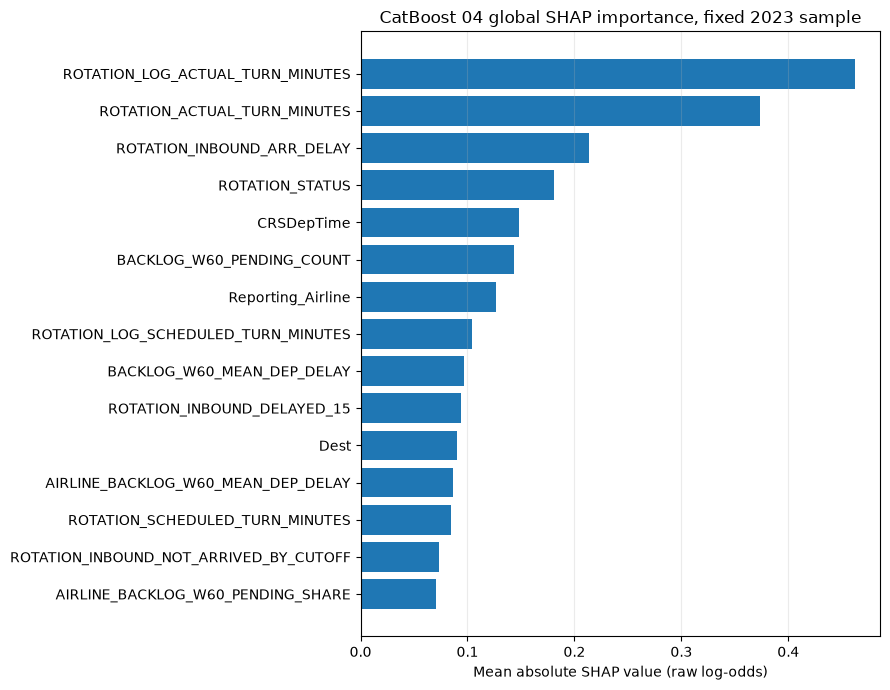

In [8]:
sample_size = min(SHAP_SAMPLE_ROWS, len(X_validation))
sample_index = np.sort(np.random.default_rng(RANDOM_STATE).choice(len(X_validation), sample_size, replace=False))
shap_pool = Pool(X_validation.iloc[sample_index], cat_features=CATEGORICAL_FEATURES)
shap_start = perf_counter()
shap_with_base = model.get_feature_importance(shap_pool, type="ShapValues")
shap_seconds = perf_counter() - shap_start
shap_values = shap_with_base[:, :-1]
shap_base = shap_with_base[:, -1]
global_shap = (pd.DataFrame({
    "feature": MODEL_FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_signed_shap": shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
print(f"Computed SHAP values for {sample_size:,} rows in {shap_seconds:,.1f} seconds")
display(global_shap.head(25))
display(global_shap[global_shap["feature"].str.contains("BACKLOG_", regex=False)])

top = global_shap.head(15).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["mean_abs_shap"])
ax.set(xlabel="Mean absolute SHAP value (raw log-odds)", title="CatBoost 04 global SHAP importance, fixed 2023 sample")
ax.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()


## Explain representative individual flights

One true negative, false positive, false negative, and true positive is selected at the frozen threshold. Within each outcome type, the example closest to that type's median predicted probability is used to avoid cherry-picking an extreme case. The table reports the five largest absolute SHAP contributions for each example and retains schedule identifiers only for audit traceability.


In [9]:
case_frame = validation_audit[[
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline", "Dest",
    "CRSDepTime", TARGET, "probability", "prediction",
]].copy()
case_frame["case_type"] = np.select(
    [
        case_frame[TARGET].eq(0) & case_frame["prediction"].eq(0),
        case_frame[TARGET].eq(0) & case_frame["prediction"].eq(1),
        case_frame[TARGET].eq(1) & case_frame["prediction"].eq(0),
        case_frame[TARGET].eq(1) & case_frame["prediction"].eq(1),
    ],
    ["true_negative", "false_positive", "false_negative", "true_positive"],
    default="unclassified",
)
representative_indices = []
for case_type in ["true_negative", "false_positive", "false_negative", "true_positive"]:
    candidates = case_frame[case_frame["case_type"].eq(case_type)]
    median_probability = candidates["probability"].median()
    representative_indices.append((candidates["probability"] - median_probability).abs().idxmin())

local_pool = Pool(X_validation.iloc[representative_indices], cat_features=CATEGORICAL_FEATURES)
local_with_base = model.get_feature_importance(local_pool, type="ShapValues")
local_rows = []
for position, row_index in enumerate(representative_indices):
    metadata = case_frame.loc[row_index]
    contributions = pd.Series(local_with_base[position, :-1], index=MODEL_FEATURES)
    for rank, feature in enumerate(contributions.abs().nlargest(5).index, start=1):
        local_rows.append({
            "case_type": metadata["case_type"], "rank": rank,
            "flight_date": metadata["FlightDate"].date(), "airline": metadata["Reporting_Airline"],
            "flight_number": metadata["Flight_Number_Reporting_Airline"], "destination": metadata["Dest"],
            "scheduled_departure": metadata["CRSDepTime"], "actual": int(metadata[TARGET]),
            "probability": metadata["probability"], "feature": feature,
            "feature_value": X_validation.loc[row_index, feature],
            "shap_raw_log_odds": contributions[feature],
        })
local_explanations = pd.DataFrame(local_rows)
local_explanations


,case_type,rank,flight_date,airline,flight_number,destination,scheduled_departure,actual,probability,feature,feature_value,shap_raw_log_odds
0,true_negative,1,2023-08-17,DL,1877,SJU,805,0,0.0729,ROTATION_LOG_ACTUAL_TURN_MINUTES,5.1475,-0.2992
1,true_negative,2,2023-08-17,DL,1877,SJU,805,0,0.0729,ROTATION_ACTUAL_TURN_MINUTES,171.0000,-0.2649
2,true_negative,3,2023-08-17,DL,1877,SJU,805,0,0.0729,CRSDepTime,805,-0.2352
3,true_negative,4,2023-08-17,DL,1877,SJU,805,0,0.0729,BACKLOG_W60_PENDING_COUNT,5,0.1981
4,true_negative,5,2023-08-17,DL,1877,SJU,805,0,0.0729,Month,8,0.1675
5,false_positive,1,2023-07-21,DL,516,LAX,1200,0,0.4174,ROTATION_LOG_ACTUAL_TURN_MINUTES,NaN,1.0340
6,false_positive,2,2023-07-21,DL,516,LAX,1200,0,0.4174,ROTATION_STATUS,PREVIOUS_EVENT_DEPARTURE,0.9637
7,false_positive,3,2023-07-21,DL,516,LAX,1200,0,0.4174,ROTATION_ACTUAL_TURN_MINUTES,NaN,0.7452
8,false_positive,4,2023-07-21,DL,516,LAX,1200,0,0.4174,ROTATION_LOG_SCHEDULED_TURN_MINUTES,NaN,-0.3555
9,false_positive,5,2023-07-21,DL,516,LAX,1200,0,0.4174,ROTATION_INBOUND_ARR_DELAY,NaN,-0.2965


## Publishable audit values and interpretation checklist

1. Confirm that the frozen refit reproduces CatBoost 04's 2023 ranking, calibration, and 0.31-threshold results.
2. Identify groups with lower ranking, low recall, or the largest absolute calibration gaps; interpret AP relative to group prevalence and avoid causal claims.
3. Confirm that traffic bands use 2019-derived boundaries and that no 2023 group result changes the model or operating policy.
4. Compare global SHAP with CatBoost 04's prediction-value-change importance, emphasizing contribution magnitude rather than causation.
5. Use representative individual explanations to show why alerts can be correct or incorrect without exposing 2024.
6. Preserve the final-tail caveat: the audit remains a retrospective upper bound until prediction-time aircraft assignment is verified.


In [10]:
worst_calibration = group_results.loc[group_results.groupby("dimension")["calibration_gap"].apply(lambda s: s.abs().idxmax())]
lowest_recall = group_results.loc[group_results.groupby("dimension")["recall"].idxmin()]
publishable_summary = pd.Series({
    "model": "CatBoost 1A Experiment 04 (unchanged)",
    "training_year": TRAIN_YEAR, "audit_year": VALIDATION_YEAR,
    "training_rows": len(y_train), "audit_rows": len(y_validation),
    "source_fields": len(MODEL_FEATURES), "threshold": FIXED_THRESHOLD,
    "validation_average_precision": reproduction["average_precision"],
    "validation_roc_auc": reproduction["roc_auc"],
    "validation_brier_score": reproduction["brier_score"],
    "validation_f1": reproduction["f1"], "validation_mcc": reproduction["mcc"],
    "shap_sample_rows": sample_size, "shap_seconds": shap_seconds,
    "largest_group_abs_calibration_gap": group_results["calibration_gap"].abs().max(),
    "minimum_group_recall": group_results["recall"].min(),
}, name="CatBoost Audit 01 Appendix E values")
display(publishable_summary.to_frame())
display(worst_calibration[["dimension", "group", "rows", "prevalence", "mean_probability", "calibration_gap", "brier_score"]])
display(lowest_recall[["dimension", "group", "rows", "prevalence", "recall", "precision", "f1"]])


,CatBoost Audit 01 Appendix E values
model,CatBoost 1A Experiment 04 (unchanged)
training_year,2019
audit_year,2023
training_rows,107430
audit_rows,109983
source_fields,41
threshold,0.3100
validation_average_precision,0.7526
validation_roc_auc,0.8546
validation_brier_score,0.1086


,dimension,group,rows,prevalence,mean_probability,calibration_gap,brier_score
5,airline,HA,362,0.2928,0.1600,-0.1328,0.1704
13,month,Jul,8596,0.3530,0.3077,-0.0453,0.1372
47,route,OTHER_LT_500,2388,0.3706,0.2692,-0.1014,0.1716
64,time_of_day,18:00-23:59,26844,0.3533,0.3159,-0.0375,0.1276
68,traffic_level,Q4_HIGH,35932,0.3199,0.2835,-0.0364,0.1262
70,weather,LOW_VISIBILITY,6510,0.2969,0.2605,-0.0364,0.1232


,dimension,group,rows,prevalence,recall,precision,f1
5,airline,HA,362,0.2928,0.2925,1.0000,0.4526
17,month,Nov,9108,0.1504,0.4343,0.7310,0.5449
34,route,HNL,658,0.2477,0.3067,0.7143,0.4292
61,time_of_day,00:00-05:59,682,0.1158,0.0759,0.3333,0.1237
65,traffic_level,Q1_LOW,18497,0.1384,0.3785,0.6762,0.4853
71,weather,NOMINAL,68776,0.2163,0.5563,0.7269,0.6303
